--- Loading and Preprocessing Data ---
Loading 5000 patients from labels.csv...
Successfully loaded 5000 patients.
Normalizing data (Z-score)...
Data ready. Class Imbalance Weight (Positive): 16.34

--- Initializing Model ---

--- Starting Training ---
Epoch 1 | Train Loss: 1.3071 | Val Loss: 1.1520
Epoch 2 | Train Loss: 1.0568 | Val Loss: 1.0294
Epoch 3 | Train Loss: 0.9288 | Val Loss: 0.9695
Epoch 4 | Train Loss: 0.8469 | Val Loss: 0.9320
Epoch 5 | Train Loss: 1.0162 | Val Loss: 0.9817
Epoch 6 | Train Loss: 0.8176 | Val Loss: 0.9260
Epoch 7 | Train Loss: 0.7625 | Val Loss: 0.9182
Epoch 8 | Train Loss: 0.6820 | Val Loss: 0.9585
Epoch 9 | Train Loss: 0.6832 | Val Loss: 0.9125
Epoch 10 | Train Loss: 0.6413 | Val Loss: 0.8583

--- Evaluating on Test Set ---


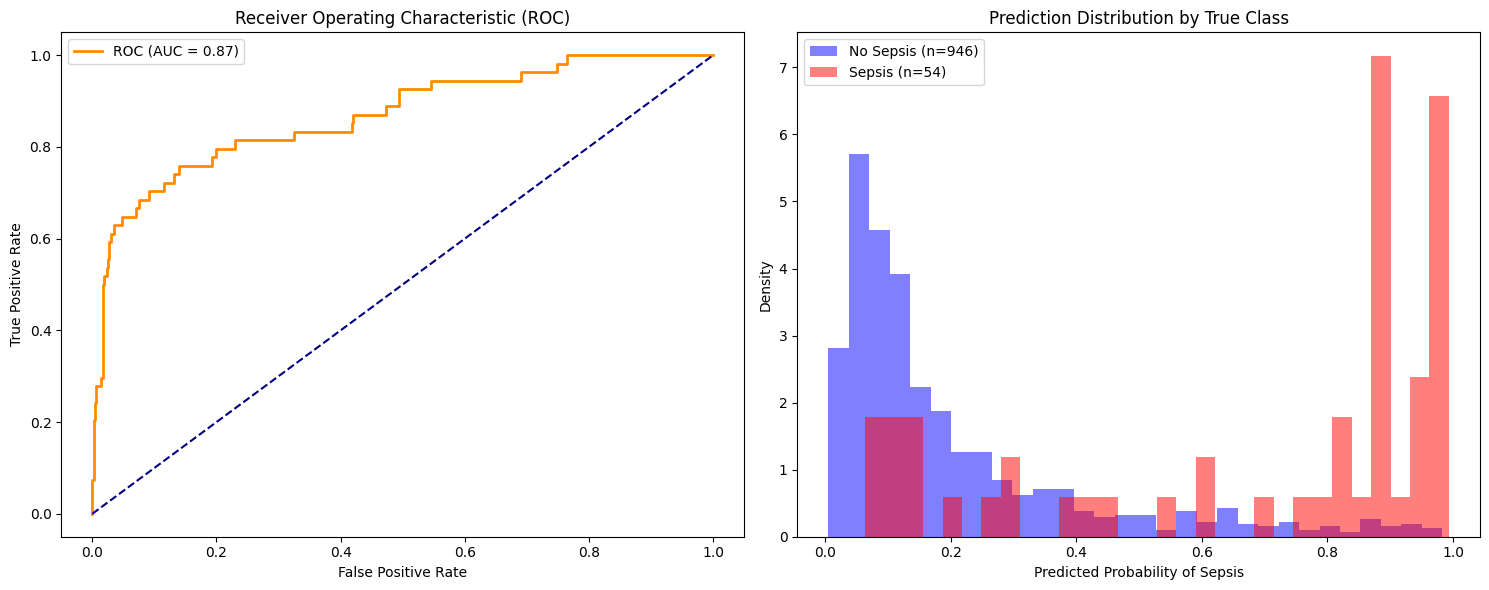

In [ ]:
import os
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import diffrax
import optax
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
MAX_PATIENTS_TO_LOAD = 20000 
BATCH_SIZE = 64
HIDDEN_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 10
MAX_SEQ_LEN = 100
INPUT_SIZE = 40
SEED = 567
LABEL_FILE = "labels.csv"

# Define columns (PhysioNet 2019 standard, 40 features)
# This list is used to assign names to the columns lacking headers in the data files.
cols = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 
    'HospAdmTime', 'ICULOS'
]

# ==========================================
# 2. ROBUST DATA LOADING (FIXED for No Headers)
# ==========================================
print("--- Loading and Preprocessing Data ---")

def load_all_data():
    """
    Load patient time series data and labels.
    Expects:
    - labels.csv in the current directory
    - time_series/ subdirectory with patient CSV files
    """
    # Labels file should be in the current directory
    label_path = LABEL_FILE
    if not os.path.exists(label_path):
        raise FileNotFoundError(f"Could not find {LABEL_FILE} in current directory.")
    
    labels_df = pd.read_csv(label_path)
    
    # APPLY PATIENT LIMIT
    num_patients_to_load = int(min(len(labels_df), MAX_PATIENTS_TO_LOAD))
    labels_to_process = labels_df.head(num_patients_to_load)
    
    print(f"Loading {num_patients_to_load} patients from labels.csv...")
    
    all_obs = []
    all_ts = []
    all_labels = []
    all_lens = []
    successful_loads = 0
    
    for _, row in labels_to_process.iterrows():
        filename = row['filename']
        # Construct path: time_series/p{id}.csv
        fpath = os.path.join('time_series', f"{filename}.csv")
        
        if os.path.exists(fpath):
            try:
                # Read CSV with NO header - features are positional
                df = pd.read_csv(fpath, header=None)
                
                # Verify we have exactly 40 columns (INPUT_SIZE)
                if df.shape[1] != INPUT_SIZE:
                    print(f"Warning: {filename} has {df.shape[1]} columns, expected {INPUT_SIZE}. Skipping.")
                    continue
                
                # Data cleaning: Forward Fill -> Backward Fill -> Zero Fill
                # Work with positional columns (no names needed)
                df = df.ffill().bfill().fillna(0.0)
                
                # Truncate/Crop to MAX_SEQ_LEN
                vals = df.values[:MAX_SEQ_LEN]
                vals = np.nan_to_num(vals)
                
                # Time steps
                ts = np.arange(len(vals), dtype=np.float32)
                
                all_obs.append(vals)
                all_ts.append(ts)
                
                # Get label
                lbl = row['label']
                all_labels.append(lbl)
                all_lens.append(len(vals))
                successful_loads += 1
                
            except Exception as e:
                print(f"Error loading {filename}: {e}")
                pass  # Skip problematic files
        else:
            print(f"File not found: {fpath}")
    
    if successful_loads == 0:
        raise ValueError("Failed to load any time series files. Check paths and data format.")
    
    print(f"Successfully loaded {successful_loads} patients.")
    return all_ts, all_obs, np.array(all_labels), np.array(all_lens)

# Execute Loader
raw_ts, raw_obs, raw_y, raw_lens = load_all_data()

# Normalize Data
print("Normalizing data (Z-score)...")
flat_obs = np.concatenate(raw_obs, axis=0)
mean_obs = np.mean(flat_obs, axis=0)
std_obs = np.std(flat_obs, axis=0) + 1e-6
norm_obs = [(x - mean_obs) / std_obs for x in raw_obs]

# Pad and Batch
def pad_data(ts_list, obs_list, labels, lengths):
    N = len(ts_list)
    max_l = max(lengths)
    
    padded_ts = np.zeros((N, max_l))
    padded_obs = np.zeros((N, max_l, INPUT_SIZE))
    
    for i in range(N):
        l = lengths[i]
        padded_ts[i, :l] = ts_list[i]
        padded_ts[i, l:] = np.arange(l, max_l) 
        padded_obs[i, :l, :] = obs_list[i]
        
    return (
        jnp.array(padded_ts), 
        jnp.array(padded_obs), 
        jnp.array(labels, dtype=jnp.float32), 
        jnp.array(lengths, dtype=jnp.int32)
    )

X_ts, X_obs, y_all, lens_all = pad_data(raw_ts, norm_obs, raw_y, raw_lens)

# Split Train / Val / Test (60% / 20% / 20%)
indices = jnp.arange(len(y_all))
train_idx, test_idx = train_test_split(indices, test_size=0.4, random_state=SEED)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED)

def get_subset(idx):
    return X_ts[idx], X_obs[idx], y_all[idx], lens_all[idx]

train_data = get_subset(train_idx)
val_data = get_subset(val_idx)
test_data = get_subset(test_idx)

# Imbalance Fix: Calculate Positive Class Weight (IMPROVEMENT SUGGESTED)
num_pos = jnp.sum(train_data[2])
num_neg = len(train_idx) - num_pos
# POS_WEIGHT > 1 increases the penalty for missing positive (Sepsis) cases.
POS_WEIGHT = num_neg / (num_pos + 1e-6) 
print(f"Data ready. Class Imbalance Weight (Positive): {POS_WEIGHT:.2f}")

# ------------------------------------------
## Model Definition
# ------------------------------------------

# ------------------------------------------
## Model Definition (FIXED - Proper Activation Handling)
# ------------------------------------------

class VectorField(eqx.Module):
    net: eqx.nn.MLP
    
    def __init__(self, hidden_size, width_size, depth, key):
        # FIX: Use a lambda wrapper to avoid storing the jitted function
        # Or use jax.nn.relu which is safer, or define custom activation
        self.net = eqx.nn.MLP(
            in_size=hidden_size, 
            out_size=hidden_size, 
            width_size=width_size,
            depth=depth, 
            activation=jax.nn.softplus,
            key=key
        )
    
    def __call__(self, t, y, args):
        return self.net(y)


class ODERNN(eqx.Module):
    vector_field: VectorField
    gru_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    hidden_size: int

    def __init__(self, in_size, hidden_size, out_size, key):
        k1, k2, k3 = jrandom.split(key, 3)
        self.hidden_size = hidden_size
        self.vector_field = VectorField(hidden_size, hidden_size, 2, k1)
        self.gru_cell = eqx.nn.GRUCell(in_size, hidden_size, key=k2)
        self.linear_out = eqx.nn.Linear(hidden_size, out_size, key=k3)

    def __call__(self, ts, obs, seq_len):
        h0 = jnp.zeros(self.hidden_size)
        init_carry = (h0, ts[0])
        xs = (ts[1:], obs[1:])

        def scan_fn(carry, x):
            h_prev, t_prev = carry
            t_curr, obs_curr = x
            
            # Ensure positive time step
            dt = jnp.maximum(t_curr - t_prev, 1e-4)
            
            # Continuous step: ODE Solve
            sol = diffrax.diffeqsolve(
                diffrax.ODETerm(self.vector_field), 
                diffrax.Tsit5(), 
                t0=t_prev, 
                t1=t_curr, 
                dt0=dt,
                y0=h_prev,
                stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
                max_steps=16
            )
            h_ode = sol.ys[0] 
            
            h_next = self.gru_cell(obs_curr, h_ode)
            return (h_next, t_curr), h_next

        _, h_history = jax.lax.scan(scan_fn, init_carry, xs)
        
        # Handle edge case: if sequence length is 1
        last_idx = jnp.maximum(seq_len - 2, 0)
        last_idx = jnp.minimum(last_idx, h_history.shape[0] - 1)
        h_final = h_history[last_idx]
        
        return self.linear_out(h_final)


# ------------------------------------------
## JAX Training Loop (FIXED)
# ------------------------------------------
print("\n--- Initializing Model ---")
model_key = jrandom.PRNGKey(SEED)
model = ODERNN(in_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, out_size=1, key=model_key)
optimizer = optax.adamw(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def compute_loss(model, batch_ts, batch_obs, batch_y, batch_lens, pos_weight):
    """JIT-compiled loss computation"""
    pred_logits = jax.vmap(model)(batch_ts, batch_obs, batch_lens).squeeze(-1)
    loss = optax.sigmoid_binary_cross_entropy(pred_logits, batch_y)
    weight_vector = jnp.where(batch_y == 1, pos_weight, 1.0) 
    return jnp.mean(loss * weight_vector)


@eqx.filter_jit
def make_step(model, opt_state, batch_ts, batch_obs, batch_y, batch_lens, pos_weight):
    """JIT-compiled training step"""
    loss_value, grads = eqx.filter_value_and_grad(compute_loss)(
        model, batch_ts, batch_obs, batch_y, batch_lens, pos_weight
    )
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value


@eqx.filter_jit
def predict(model, batch_ts, batch_obs, batch_lens):
    logits = jax.vmap(model)(batch_ts, batch_obs, batch_lens)
    return jax.nn.sigmoid(logits.squeeze(-1))


def get_batches(data, batch_size, key):
    ts, obs, y, lens = data
    data_size = len(y)
    indices = jnp.arange(data_size)
    perm = jrandom.permutation(key, indices)
    for i in range(0, data_size, batch_size):
        idx = perm[i : i + batch_size]
        yield ts[idx], obs[idx], y[idx], lens[idx]


print("\n--- Starting Training ---")
train_key = jrandom.PRNGKey(SEED + 1)
for epoch in range(EPOCHS):
    train_key, subkey = jrandom.split(train_key)
    train_loss = 0
    batches = 0
    for b_ts, b_obs, b_y, b_lens in get_batches(train_data, BATCH_SIZE, subkey):
        model, opt_state, loss = make_step(model, opt_state, b_ts, b_obs, b_y, b_lens, POS_WEIGHT)
        train_loss += loss.item()
        batches += 1
    
    val_loss = compute_loss(model, *val_data, POS_WEIGHT).item()
    print(f"Epoch {epoch+1} | Train Loss: {train_loss/batches:.4f} | Val Loss: {val_loss:.4f}")

# ------------------------------------------
## Evaluation and Graphing
# ------------------------------------------
print("\n--- Evaluating on Test Set ---")
test_ts, test_obs, test_y, test_lens = test_data
test_preds = []

# Infer in chunks for memory safety
for i in range(0, len(test_y), 128):
    p = predict(model, test_ts[i:i+128], test_obs[i:i+128], test_lens[i:i+128])
    test_preds.append(p)
test_preds = jnp.concatenate(test_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: ROC Curve (Compare Predictions to Actual Labels)
fpr, tpr, _ = roc_curve(test_y, test_preds)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], linestyle='--', color='navy')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()


# Plot 2: Prediction Distribution (Imbalance visualization)
pos_preds = test_preds[test_y==1]
neg_preds = test_preds[test_y==0]

ax2.hist(neg_preds, bins=30, alpha=0.5, label=f'No Sepsis (n={len(neg_preds)})', density=True, color='blue')
ax2.hist(pos_preds, bins=30, alpha=0.5, label=f'Sepsis (n={len(pos_preds)})', density=True, color='red')
ax2.set_title('Prediction Distribution by True Class')
ax2.set_xlabel('Predicted Probability of Sepsis')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()